# Week 9 Overview

This week will be a mix of data vizualization problems and . 

The first 5 problems are data cleaning and the final 4 problems are linear algebra. 

### Data Visualization

Data visualization is a key part of exploratory data analysis (EDA), a crucial initial step for understanding a dataset and preparing for statistical modeling.

Helps visually answer questions such as:
- what patterns are evident in the data?
- what variables are important?
- does the data have anomalies or outliers?

Data visualization is also used throughout the data analysis process to show results and convey information to stakeholders.

Typically, EDA uses `histograms` & `box plots` to visualize `distribution` of a single continuous variable. `Bar charts` & `scatterplots` are used for `bivariate analysis` - correlation between two variables.


#### Histograms

![histograms](https://raw.githubusercontent.com/brendenwest/cis276/main/images/histograms.png)

Display the distribution of a continuous variable.
- Useful for visualizing the shape, for identifying
patterns or trends, for detecting
outliers, skewness, or multimodality
- Divides data into equal-width intervals (`bins`)
- Height of each `bar` represents frequency or
`count` of observations
- Can also compare the distribution of two
or more variables


#### Box & Whisker Plots

A box plot can show how tightly data is grouped, how the data is skewed, and also the symmetry of data.

![image](https://cdn1.byjus.com/wp-content/uploads/2020/10/Box-Plot-and-Whisker-Plot-2.png)

Display `median`, `quartiles`, and outliers.
- Useful for visualizing the distribution and spread.
- Box represents `interquartile range` (IQR)
- Line inside the box represents the median
- Whiskers extend from box to minimum and maximum values within 1.5 times the IQR from the box
- Values outside of this range are considered outliers and plotted as individual points


#### Scatterplots

Scatter (aka X-Y) plots show the relationship between two continuous variables. Also useful for identifying outlier data points.

![scatterplots](https://www.mathsisfun.com/data/images/correlation-examples.svg)



#### Bar Charts

Useful for visualizing distribution of `categorical` variables through relative size of bars.

-  One axis represents categories being compared
- Other axis represents frequency, count, or percentage of each category
- usually has space between bars to avoid confusion with histograms

![bar_chart](https://www.mathsisfun.com/data/images/bar-chart-movies.svg)


### Plotting with matplotlib

matplotlib is python package designed for creating (mostly two-dimensional) publication-quality plots.

It allows interactive plotting from the iPython shell or within Jupyter notebooks

matplotlib can export visualizations to  common vector and raster graphics formats (PDF, SVG, JPG, PNG, BMP, GIF, etc.).

- plots & plot types
- title & labels
- legends
- subplots
- annotations
- saving plots

### Plotting with pandas

The pandas `plot()` method is a wrapper for matplotlib's pyplot.plot() and produces the same plots, but with simpler syntax for visualizing dataframes.
`.plot()` has several optional parameters. Most notably, the `kind` parameter  determines which kind of plot you’ll create (default is a `line` plot):

- "area" for area plots.
- "bar" for vertical bar charts.
- "barh" for horizontal bar charts.
- "box" for box plots.
- "hexbin" for hexbin plots.
- "hist" for histograms.
- "kde" for kernel density estimate charts.
- "density" an alias for "kde".
- "line" for line graphs.
- "pie" for pie charts.
- "scatter" for scatter plots.

### Plotting with seaborn

Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures.

Seaborn not only makes it easier than pandas to prepare a wider variety of plots, but supports enhancements for presentation-quality plots.

Seaborn supports several key types of plots:

- **relational** - show the relationship between two numeric variables. Includes scatter plots and line plots
- **categorical** - compare data in different categories
- **distribution** - examine how numeric data is distributed across a range of values. Types of distribution plots are histogram, kernel density estimate (KDE) plot, and empirical cumulative distribution function (ECDF) plot
- **predictive** - plots that are designed for predictive analysis, such as for linear regression models.

#### Seaborn styles

`set_style(style)`
Sets the background style with one of these values: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks` (the default). This style stays in effect until it is changed by another set_style() call.
#### General vs. specific methods

You can create Seaborn plots using the general `relplot()` command, which expects a `kind` parameter.

Alternatively, you can use a specific method - e.g. `lineplot()`, which does not require a `kind` parameter.

The two approaches mostly produce the same result, but the the general methods let you create plots with subplots, while the specific methods don’t.

So the general methods return a `FacetGrid` object that contains an `Axes` object for each subplot. The specific methods return an `Axes` object.

#### Basic Seaborn plot parameters

- data - the DataFrame of data to plot
- kind - the type of plot (general plots only)
- x, y - data columns for the x- and y-axis
- hue -  the column that determines categories to plot, with different color for each category
- palette -  color pallette for the plot
- height - The height of the plot in inches with a default of 5. (general plots only)
- aspect - the ratio of width to height (general plots only)
- legend - options for how the legend will be drawn: `auto` (the default), `brief`, `full`, and `False`. (general plots only)

#### Creating subplots

- By default, x and y labels are shared by subplots
- subplots get their title from the category label

#### Modifying plot features

The `Axes` object that provides methods for enhancing a plot.

#### Saving plots

Seaborn plots can be saved to PNG, SVG, or PDF files. The approach is slightly different for plots created with general or specific methods.

- **General method** - assign the plot's FacetGrid object to a variable and then use the `savefig()` method of the FacetGrid object
- **Specific method** - call the `get_figure()` method on the Axes object  returned by the lineplot() method, then chain go the `savefig()` method

# Data Visualization Problems

For the problems this week we are going to go a step deeper and start to ask questions about our data. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::disability-and-health-insurance-seattle-neighborhoods/about
dis_health_df = pd.read_csv('seattle_data/disability_health_insurance_Neighborhoods.csv')
dis_health_df.columns = [i.replace(" ", "_") for i in dis_health_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::poverty-and-employment-status-seattle-neighborhoods/about
income_df = pd.read_csv('seattle_data/incomes_Neighborhoods.csv')
income_df.columns = [i.replace(" ", "_") for i in income_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::incomes-occupations-and-earnings-seattle-neighborhoods/about
poverty_df = pd.read_csv('seattle_data/poverty_Neighborhoods.csv')
poverty_df.columns = [i.replace(" ", "_") for i in poverty_df.columns]

In [2]:
display("Disability and health insurance")
display(dis_health_df.info())

'Disability and health insurance'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 37 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   OBJECTID                                                         92 non-null     int64  
 1   NEIGH_NO                                                         92 non-null     float64
 2   Neighborhood_Name                                                92 non-null     object 
 3   Neighborhood_Type                                                92 non-null     object 
 4   Neighborhood_Subtype                                             85 non-null     object 
 5   ACS_Vinatage                                                     92 non-null     object 
 6   Population_18_years_and_Over                                     92 non-null     int64  
 7   Population_18_to_64_years                     

None

In [3]:
display("Poverty and employment status")
display(income_df.info())

'Poverty and employment status'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 69 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   OBJECTID                                                                     92 non-null     int64  
 1   NEIGH_NO                                                                     92 non-null     float64
 2   Neighborhood_Name                                                            92 non-null     object 
 3   Neighborhood_Type                                                            92 non-null     object 
 4   Neighborhood_Subtype                                                         85 non-null     object 
 5   ACS_Vinatage                                                                 92 non-null     object 
 6   Aggregate_income_in_the_past_12_months_(in_2

None

In [4]:
display("Occupations and earnings")
display(poverty_df.info())

'Occupations and earnings'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 36 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   OBJECTID                                                                                        92 non-null     int64  
 1   NEIGH_NO                                                                                        92 non-null     float64
 2   Neighborhood_Name                                                                               92 non-null     object 
 3   Neighborhood_Type                                                                               92 non-null     object 
 4   Neighborhood_Subtype                                                                            85 non-null     object 
 5   ACS_Vinatage     

None

In [5]:
display("Disability and health insurance, first 18 columns")
display(dis_health_df.iloc[:25, 0:18])
display("Disability and health insurance, columns 19+")
display(dis_health_df.iloc[:25, 19:])

'Disability and health insurance, first 18 columns'

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Population_18_years_and_Over,Population_18_to_64_years,Population_18_to_64_years_Below_Poverty_with_a_Disability,Population_18_to_64_years_Below_Poverty_without_a_Disability,Population_18_to_64_years_Above_Poverty_with_a_Disability,Population_18_to_64_years_Above_Poverty_without_a_Disability,Population_65_years_and_Over,Population_65_years_and_Over_Below_Poverty_with_a_Disability,Population_65_years_and_Over_Below_Poverty_without_a_Disability,Population_65_years_and_Over_Above_Poverty_with_a_Disability,Population_65_years_and_Over_Above_Poverty_without_a_Disability,Population_18_years_and_Over_with_a_Disability
0,1,1.4,Alki/Admiral,CRA,Southwest,5Y23,10131,7910,105,323,485,6997,2221,9,33,503,1676,1102
1,2,2.1,North Delridge,CRA,Delridge Neighborhoods,5Y23,5213,4629,28,408,316,3877,584,11,12,136,425,491
2,3,2.2,High Point,CRA,Delridge Neighborhoods,5Y23,6828,6084,128,584,398,4974,744,73,39,274,358,873
3,4,2.3,Riverview,CRA,Delridge Neighborhoods,5Y23,3940,3497,29,147,189,3132,443,22,53,80,288,320
4,5,2.4,Roxhill/Westwood,CRA,Delridge Neighborhoods,5Y23,11602,10014,397,454,606,8557,1588,119,90,550,829,1672
5,6,2.5,Highland Park,CRA,Delridge Neighborhoods,5Y23,6641,5365,103,327,419,4516,1276,41,62,441,732,1004
6,7,3.1,South Park,CRA,Greater Duwamish,5Y23,2933,2647,178,310,186,1973,286,7,43,161,75,532
7,8,3.2,Georgetown,CRA,Greater Duwamish,5Y23,1066,912,13,94,44,761,154,0,8,49,97,106
8,9,3.3,Duwamish/SODO,CRA,Greater Duwamish,5Y23,2926,2417,42,253,107,2015,509,27,61,144,277,320
9,10,3.4,South Beacon Hill/NewHolly,CRA,Greater Duwamish,5Y23,12499,9903,259,1385,598,7661,2596,283,444,733,1136,1873


'Disability and health insurance, columns 19+'

,Population_65_years_and_Over_with_a_Disability,Population_Civilian_Noninstitutionalized,Population_under_19_years_with_Health_Insurance,Population_under_19_years_without_Health_Insurance,Population_19_to_34_years_with_Health_Insurance,Population_19_to_34_years_without_Health_Insurance,Population_35_to_64_years_with_Health_Insurance,Population_35_to_64_years_without_Health_Insurance,Population_65_years_and_Over_with_Health_Insurance,Population_65_years_and_Over_without_Health_Insurance,Population_without_Health_Insurance,Population_under_19_years,Population_19_to_34_years,Population_35_to_64_years,Population_65_years_and_Over.1,Households,Households_with_1_or_more_persons_with_a_disability,Neighborhood_Type_(outside_comp_plan_areas_id)
0,512,11920,1862,0,2172,59,5218,388,2221,0,447,1862,2231,5606,2221,5595,865,CRA
1,147,5743,558,0,1621,163,2460,357,584,0,520,558,1784,2817,584,3079,452,CRA
2,347,9194,2392,15,2505,90,3274,174,744,0,279,2407,2595,3448,744,3709,756,CRA
3,102,5014,1114,1,1070,18,2315,53,437,6,78,1115,1088,2368,443,1878,329,CRA
4,669,13964,2501,58,3109,496,5771,441,1540,48,1043,2559,3605,6212,1588,5825,1171,CRA
5,482,8131,1556,57,1677,104,3183,278,1215,61,500,1613,1781,3461,1276,3253,834,CRA
6,168,3916,1028,0,767,257,1358,220,279,7,484,1028,1024,1578,286,1482,398,CRA
7,49,1181,120,0,241,61,521,84,154,0,145,120,302,605,154,702,96,CRA
8,171,3170,244,0,961,113,1213,130,494,15,258,244,1074,1343,509,1628,256,CRA
9,1016,15593,3141,86,3559,404,5405,402,2560,36,928,3227,3963,5807,2596,4920,1433,CRA


In [6]:
display("Poverty and employment status, first 18 columns")
display(income_df.iloc[:25, :25])
display("Poverty and employment status, columns 26-50")
display(income_df.iloc[:25, 26:50])
display("Poverty and employment status, columns 51+")
display(income_df.iloc[:25, 51:])

'Poverty and employment status, first 18 columns'

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Aggregate_income_in_the_past_12_months_(in_2022_inflation-adjusted_dollars),Total_Population,Total_Households,"Household_Income_Less_than_$10,000",...,"Household_Income_$75,000_to_$99,999","Household_Income_$100,000_to_$149,999","Household_Income_$150,000_to_$199,999","Household_Income_$200,000_or_more",Total_Family_Households,"Family_Household_Income_Less_than_$10,000","Family_Household_Income_$10,000_to_$14,999","Family_Household_Income_$15,000_to_$24,999","Family_Household_Income_$25,000_to_$34,999","Family_Household_Income_$35,000_to_$49,999"
0,1,1.0,Council District 1,CD,NaN,5Y23,7965084000,108594,48209,NaN,...,4778,8682,6337,13189,25525,NaN,281,366,710,1365
1,2,2.0,Council District 2,CD,NaN,5Y23,6355394800,108053,43824,NaN,...,4223,6708,4757,9749,23697,NaN,482,1102,791,1541
2,3,3.0,Council District 3,CD,NaN,5Y23,10763937200,108012,60156,NaN,...,5784,9201,6839,17110,18845,NaN,216,266,257,1011
3,4,4.0,Council District 4,CD,NaN,5Y23,7692298500,104299,42569,NaN,...,3530,6034,3970,13520,18862,NaN,101,233,286,481
4,5,5.0,Council District 5,CD,NaN,5Y23,7324865100,106208,47887,NaN,...,5929,8317,5415,11117,23890,NaN,182,530,476,1127
5,6,6.0,Council District 6,CD,NaN,5Y23,10191916300,105404,50023,NaN,...,4579,7844,6071,19240,23414,NaN,272,142,184,466
6,7,7.0,Council District 7,CD,NaN,5Y23,10919759000,101881,60719,NaN,...,4835,10836,8614,19260,17004,NaN,46,71,382,324
7,8,1.1,Arbor Heights,CRA,Southwest,5Y23,507483100,6145,2693,NaN,...,358,481,397,887,1839,NaN,8,18,10,53
8,9,1.2,Fauntleroy/Seaview,CRA,Southwest,5Y23,1300068000,15120,6879,NaN,...,547,1093,1143,2272,3865,NaN,18,0,62,64
9,10,1.3,West Seattle Junction/Genesee Hill,CRA,Southwest,5Y23,1894282400,23800,11240,NaN,...,1016,2071,1346,3305,5391,NaN,91,54,79,196


'Poverty and employment status, columns 26-50'

,"Family_Household_Income_$75,000_to_$99,999","Family_Household_Income_$100,000_to_$149,999","Family_Household_Income_$150,000_to_$199,999","Family_Household_Income_$200,000_or_more",Total_Nonfamily_Housholds,"Nonfamily_Household_Income_Less_than_$10,000","Nonfamily_Household_Income_$10,000_to_$14,999","Nonfamily_Household_Income_$15,000_to_$24,999","Nonfamily_Household_Income__$25,000_to_$34,999","Nonfamily_Household_Income_$35,000_to_$49,999",...,"Nonfamily_Household_Income_$200,000_or_more","Management,_business,_science,_and_arts_occupations",Service_occupations,Sales_and_office_occupations,"Natural_resources,_construction,_and_maintenance_occupations","Production,_transportation,_and_material_moving_occupations","Earnings_Male_less_than_$10,000","Earnings_Male_$10,000_to_$19,999","Earnings_Male_$20,000_to_$39,999","Earnings_Male_$40,000_to_$74,999"
0,2067,4503,4223,9580,22684,NaN,928,1121,1562,2208,...,3394,37499,8102,10459,2500,4652,2868,1735,4141,7945
1,2392,3798,3245,7220,20127,NaN,2091,1463,1282,1875,...,2096,31618,11227,9591,2784,5520,3638,2171,5239,10268
2,1030,2075,2578,9449,41311,NaN,1170,1973,2298,3013,...,7474,52397,6872,9184,1234,2282,3556,1685,5452,8931
3,1047,2851,2401,10186,23707,NaN,1094,1696,1652,2496,...,3005,40698,7351,8905,1239,2583,5554,2505,3734,6248
4,2471,4228,3550,8332,23997,NaN,1333,1803,1376,2697,...,2440,37531,8451,9354,2580,4668,2869,2492,4824,8731
5,1377,2929,3146,13737,26609,NaN,1168,1125,945,2014,...,5211,49399,5301,8129,1552,2695,1892,1231,2618,7059
6,803,2501,2228,9472,43715,NaN,1433,2025,2156,2638,...,9665,54906,5942,8778,1116,2251,1793,1545,3543,6363
7,185,362,314,770,854,NaN,0,14,64,51,...,95,2308,146,474,117,108,75,25,77,294
8,259,644,805,1689,3014,NaN,220,138,198,334,...,550,5762,1013,1435,399,392,397,204,588,773
9,307,857,956,2384,5849,NaN,193,190,564,459,...,887,9398,1265,2599,401,1066,747,504,820,1623


'Poverty and employment status, columns 51+'

,"Earnings_Male_$100,000_or_more","Earnings_Female_less_than_$10,000","Earnings_Female_$10,000_to_$19,999","Earnings_Female_$20,000_to_$39,999","Earnings_Female_$40,000_to_$74,999","Earnings_Female_$75,000_to_$99,999","Earnings_Female_$100,000_or_more","Household_Income_$100,000_or_more","Family_Household_Income_$100,000_or_more","Nonfamily_Household_Income_$100,000_or_more","Earnings_$50,000_or_More_Male_Workers","Earnings_$50,000_or_More_Female_Workers",Population_16_years_and_over_with_earnings,Males_16_years_and_over_with_earnings,Females_16_years_and_over_with_earnings,"Earnings_$50,000_or_More_All_Workers",Aggregate_Household_Income,Neighborhood_Type_(outside_comp_plan_areas_id)
0,15783,3410,2449,4518,7726,4804,9516,28208,18306,9460,25368,19332,69022,36599,32423,44700,7797458400,CD
1,10660,4260,2358,6093,8193,3167,6591,21214,14263,6486,20961,14994,66298,35636,30662,35955,6177651600,CD
2,19716,3749,2112,4462,8998,4129,11812,33150,14102,18831,30371,22452,79057,43795,35262,52823,10593211500,CD
3,14832,7436,3782,5203,6948,3839,7516,23524,15438,7902,21817,15841,70502,35778,34724,37658,7471995100,CD
4,12825,3635,2105,4497,8702,4217,8054,24849,16110,8266,23739,18286,68025,36815,31210,42025,7154789000,CD
5,19278,2706,1795,3686,8985,5009,12558,33155,19812,13304,29435,23508,71896,37157,34739,52943,10087849700,CD
6,25198,2823,2338,4336,8145,4293,13663,38710,14201,24414,34036,23614,78442,42844,35598,57650,10779928000,CD
7,849,220,114,171,313,374,655,1765,1446,308,1252,1274,3325,1478,1847,2526,507110300,CRA
8,2502,505,309,659,956,620,1625,4508,3138,1330,3745,2852,9744,5070,4674,6597,1287130400,CRA
9,4385,843,688,864,1428,1002,2159,6722,4197,2422,6590,4246,15993,9009,6984,10836,1857993300,CRA


In [7]:
display("Occupations and earnings, first 18 columns")
display(poverty_df.iloc[:25, :18])
display("Occupations and earnings, columns 19+")
display(poverty_df.iloc[:25, 19:])

'Occupations and earnings, first 18 columns'

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Population_16_years_and_over,Population_16_years_and_over_not_in_labor_force,Population_16_years_and_over_in_civilian_labor_force,Population_16_years_and_over_in_civilian_labor_force_unemployed,Population_for_whom_poverty_status_is_determined,People_with_Income_to_Poverty_Ratio_Under_.50,People_with_Income_to_Poverty .50_to_.99,People_with_Income_to_Poverty_1.00_to_1.24,People_with_Income_to_Poverty 1.25_to_1.49,People_with_Income_to_Poverty 1.50_to_1.84,People_with_Income_to_Poverty 1.85_to_1.99,People_with_Income_to_Poverty_2.00_and_over
0,1,8.2,Olympic Hills/Victory Heights,CRA,North,5Y23,14516,3751,10745,574,17039,670,717,376,426,594,168,14088
1,2,8.3,Cedar Park/Meadowbrook,CRA,North,5Y23,12513,3677,8836,259,14445,498,824,497,287,582,119,11638
2,3,9.1,Broadview/Bitter Lake,CRA,Northwest,5Y23,13260,4753,8507,356,15645,676,1105,173,291,898,118,12384
3,4,9.2,Licton Springs,CRA,Northwest,5Y23,8798,1895,6903,267,9597,631,429,145,310,411,155,7516
4,5,9.3,Greenwood/Phinney Ridge,CRA,Northwest,5Y23,23396,4985,18381,565,26912,854,371,241,395,417,335,24299
5,6,9.4,Green Lake,CRA,Northwest,5Y23,15265,3477,11779,498,17425,513,784,338,463,431,96,14800
6,7,9.5,Haller Lake,CRA,Northwest,5Y23,8986,2220,6766,316,10866,512,325,103,126,156,89,9555
7,8,10.1,North Beach/Blue Ridge,CRA,Ballard,5Y23,10485,2784,7654,343,12716,252,601,83,141,144,112,11383
8,9,10.2,Whittier Heights,CRA,Ballard,5Y23,12384,2446,9938,173,14552,402,522,48,159,258,107,13056
9,10,10.3,Sunset Hill/Loyal Heights,CRA,Ballard,5Y23,13443,3746,9638,307,16151,221,404,172,67,164,110,15013


'Occupations and earnings, columns 19+'

,Families_with_income_in_the_past_12_months_below_poverty_level,Married-couple_family_with_related_children_of_the_householder_under_18_years_below_poverty,Married-couple_family_without_related_children_of_the_householder_under_18_years_below_poverty,Single_parents_with_related_children_of_the_householder_under_18_years_below_poverty,Other_family_below_poverty,Population_20_to_64_years_for_whom_poverty_status_is_determined,Population_20_to_64_years_below_poverty,Population_20_to_64_years_employed,Population_20_to_64_years_below_poverty_employed,People_with_Income_to_Poverty_below_2.00,Population_20_to_64_years_in_civilian_labor_force,Population_20_to_64_years_in_civilian_labor_force_below_poverty,Population_20_to_64_years_not_in_labor_force,Population_20_to_64_years_not_in_labor_force_below_poverty,Population_20_to_64_years_unemployed,Population_20_to_64_years_unemployed_below_poverty,Neighborhood_Type_(outside_comp_plan_areas_id)
0,156,0,29,67,60,11633,887,9637,392,2951,10165,594,1448,293,528,202,CRA
1,169,54,28,49,38,9389,843,7774,250,2807,7985,321,1404,522,211,71,CRA
2,242,9,49,161,23,9295,861,7454,285,3261,7776,371,1519,490,322,86,CRA
3,92,0,13,13,66,7609,712,6339,201,2081,6601,301,1008,411,262,100,CRA
4,117,35,12,65,5,19323,886,16629,324,2613,17105,456,2188,430,476,132,CRA
5,92,7,9,50,26,12509,966,10702,289,2625,11200,441,1300,525,498,152,CRA
6,127,51,0,76,0,7420,433,6080,264,1311,6364,342,1056,91,284,78,CRA
7,136,30,0,36,70,8116,690,6776,278,1333,7119,444,950,246,343,166,CRA
8,107,0,0,55,52,10946,750,9445,307,1496,9609,376,1337,374,164,69,CRA
9,95,11,14,70,0,10227,323,8635,152,1138,8883,152,1285,171,248,0,CRA


## Problem 1: Asking Questions (10 pts)

Take 5 minutes to look through the above data sources as pose 5 analytical questions you might want to ask with that data. By analytical I mean question will drive informative analysis. For example:

**Good Question**: Is there relationship between health insurance coverage and disability?

**Bad Question**: How many neighboorhoods are there?

The second question is the type of question that is is good to ask when processing the data to make sure you processed it correctly but it doesn't give you insights into the data.

At least two of the questions must involve data from at least two of the datasets.

In class you will share your questions with your group and as a group you will pick two questions to focus on for analysis in class. On your own this week you will answer the rest of your questions.

**Grading**
You will receive 2 points per question. One point for forming a question the other for it being a analytical question. 

In [8]:
print("1. How does poverty correlate with employment across neighborhoods?")

print("2. Does lower income correlate with disability?")

print("3. How does neighborhood correlate with health insurance?")

print("4. How does disability correlate with age?")

print("5. How does neighborhood correlate with disability?")



1. How does poverty correlate with employment across neighborhoods?
2. Does lower income correlate with disability?
3. How does neighborhood correlate with health insurance?
4. How does disability correlate with age?
5. How does neighborhood correlate with disability?


## Problem 2: Data Cleaning and Merging (10 pts)

Take a few minutes to prepare your data for analysis. You can decide what preparation is required but you must at least perform two of the following to receive credit. You might find that you start to create a graph and then need to prepare the data better (i.e. remove an outlier) that is expected.

1. Clean up the column names.
2. Merge dataframes together. 
3. Fill in null values.
4. Removing outliers. 
5. Change the shape of the data (We will learn aggregations next week but if you know how feel free to use them).
6. Any other preparation required to answer your questions.

For each preparation step add a comment to explain why you did that step. 

**Grading** You will receive 5 points for the first two data prep steps you perform. 2 point will be for the comment and then 3 points will be for accurately performing the prep. 

In [9]:
""" 
disability_health_insurance_Neighborhoods.csv
dis_health_df

incomes_Neighborhoods.csv
income_df

poverty_Neighborhoods.csv
poverty_df 
"""

# Shorten column names as some of them are very long and it is tedious to 
# scroll that far right, also drop all entries with an NA
dis_health_df_renamed = dis_health_df.rename(columns = {"Population_18_years_and_Over": "Pop_18+", "Population_18_to_64_years": "Pop_18-64"})

# merged dis_health_df and poverty_df with the neighborhood numbers
health_dis_pov_df = pd.merge(dis_health_df, poverty_df, on="NEIGH_NO", how="inner")



## Problem 3: Question 1 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

disability_health_insurance_Neighborhoods.csv
dis_health_df

incomes_Neighborhoods.csv
income_df

poverty_Neighborhoods.csv
poverty_df 

1. How does poverty correlate with employment?

I found that there is a linear relationship with poverty and unemployment. Lower poverty rates correlate 
with lower unemployment rates.

I added a title for the chart as well as title as well as x/y axis labels so the chart is easy to follow. 

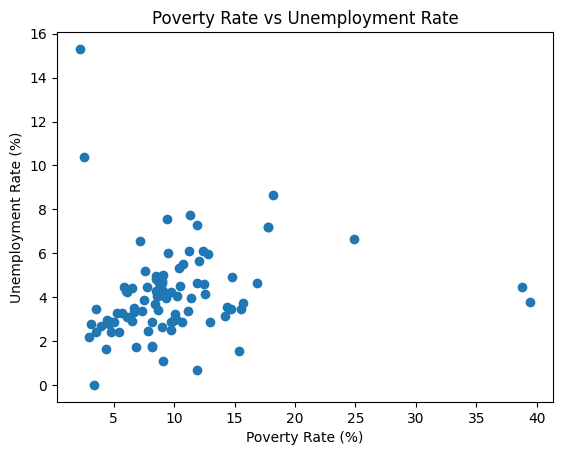

In [10]:
poverty_rate = poverty_df["poverty_rate"] = (
    poverty_df["Population_20_to_64_years_below_poverty"] /
    poverty_df["Population_20_to_64_years_for_whom_poverty_status_is_determined"]
) * 100

unemployment_rate = poverty_df["unemployment_rate"] = (
    poverty_df["Population_20_to_64_years_unemployed"] /
    poverty_df["Population_20_to_64_years_in_civilian_labor_force"]
) * 100

plt.scatter(poverty_rate, unemployment_rate)
plt.title("Poverty Rate vs Unemployment Rate")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.show()

## Problem 4: Question 2 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

disability_health_insurance_Neighborhoods.csv
dis_health_df

incomes_Neighborhoods.csv
income_df

poverty_Neighborhoods.csv
poverty_df 

2. How does income correlate with disability?

I found a linear relationship between income and disability. I combined 3 columns of income that are all below 35K into a new column 
named low_income_rate. 

I added a title for the chart as well as x/y axis labels. 

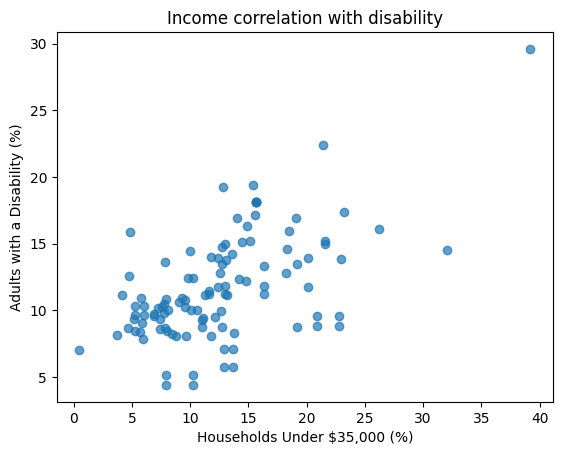

In [11]:
dis_health_df["disability_rate"] = (
    dis_health_df["Population_18_years_and_Over_with_a_Disability"] /
    dis_health_df["Population_18_years_and_Over" \
    ""]
) * 100

income_df["low_income_rate"] = (
    income_df["Household_Income_$10,000_to_$14,999"] +
    income_df["Household_Income_$15,000_to_$24,999"] +
    income_df["Household_Income_$25,000_to_$34,999"]
) / income_df["Total_Households"] * 100

income_disability = income_df.merge(
    dis_health_df,
    left_on="Neighborhood_Name",
    right_on="Neighborhood_Name",
    how="inner"
)

plt.scatter(
    income_disability["low_income_rate"],
    income_disability["disability_rate"],
    alpha=0.7
)
plt.title("Income correlation with disability")
plt.xlabel("Households Under $35,000 (%)")
plt.ylabel("Adults with a Disability (%)")
plt.show()

## Problem 5: Question 3 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

disability_health_insurance_Neighborhoods.csv
dis_health_df

incomes_Neighborhoods.csv
income_df

poverty_Neighborhoods.csv
poverty_df 

3. How does neighborhood correlate with health insurance?

I noticed that neighborhoods in the southern part of the city have higher levels of uninsured 
individuals. 

I added title to the chart and x/y axis and also inverted the y-axis so the neighborhoods with 
the highest level of uninsured individuals were at the top.

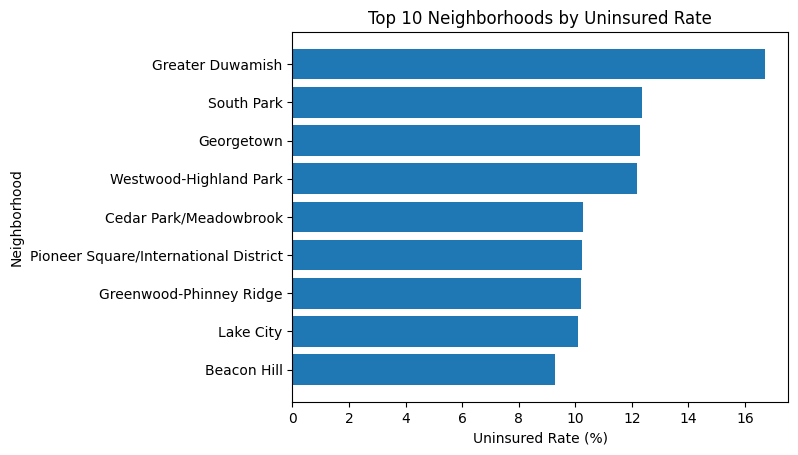

In [12]:
dis_health_df["uninsured_rate"] = (
    dis_health_df["Population_without_Health_Insurance"] /
    dis_health_df["Population_Civilian_Noninstitutionalized"]
) * 100

top_uninsured = dis_health_df.sort_values(
    "uninsured_rate",
    ascending=False
).head(10)

plt.barh(
    top_uninsured["Neighborhood_Name"],
    top_uninsured["uninsured_rate"]
)
plt.title("Top 10 Neighborhoods by Uninsured Rate")
plt.xlabel("Uninsured Rate (%)")
plt.ylabel("Neighborhood")
plt.gca().invert_yaxis()
plt.show()

## Problem 6: Question 4 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

disability_health_insurance_Neighborhoods.csv
dis_health_df

incomes_Neighborhoods.csv
income_df

poverty_Neighborhoods.csv
poverty_df 

4. How does disability correlate with age?

I found that disabilites were much higher with those 65 years old and above. 

I added titles to the char and x/y axis. I also used ticks to show the neighborhood names 
along the x-axis along with a legend and also tight to space everything out a little more 
so it wasn't crowded.

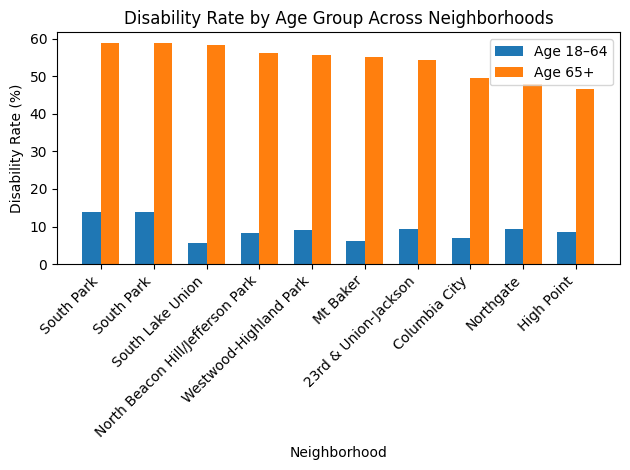

In [13]:
dis_health_df["disability_rate_18_64"] = (
    dis_health_df["Population_18_to_64_years_with_a_Disability"] /
    dis_health_df["Population_18_to_64_years"]
) * 100

dis_health_df["disability_rate_65_plus"] = (
    dis_health_df["Population_65_years_and_Over_with_a_Disability"] /
    dis_health_df["Population_65_years_and_Over"]
) * 100

top_age_compare = dis_health_df.sort_values(
    "disability_rate_65_plus",
    ascending=False
).head(10)

x = np.arange(len(top_age_compare))
width = 0.35

plt.bar(
    x - width / 2,
    top_age_compare["disability_rate_18_64"],
    width,
    label="Age 18–64"
)
plt.bar(
    x + width / 2,
    top_age_compare["disability_rate_65_plus"],
    width,
    label="Age 65+"
)
plt.title("Disability Rate by Age Group Across Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Disability Rate (%)")
plt.xticks(x, top_age_compare["Neighborhood_Name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Problem 7: Question 5 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

disability_health_insurance_Neighborhoods.csv
dis_health_df

incomes_Neighborhoods.csv
income_df

poverty_Neighborhoods.csv
poverty_df 

5. How does neighborhood correlate with disability?

I found that neighborhoods in the southern part of the city have more people with disabilities. 

I added a title to the chart and also the x/y axis and also inverted the chart so the neighborhoods 
with the highest values were at the top.

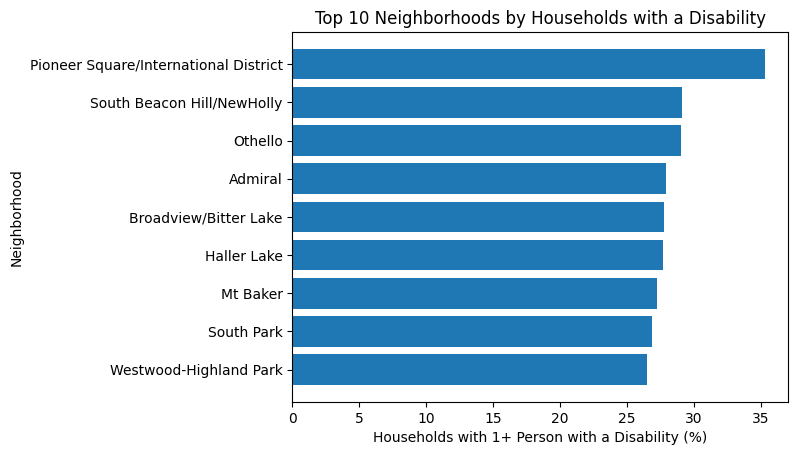

In [14]:
dis_health_df["household_disability_rate"] = (
    dis_health_df["Households_with_1_or_more_persons_with_a_disability"] /
    dis_health_df["Households"]
) * 100

top_household_dis = dis_health_df.sort_values(
    "household_disability_rate",
    ascending=False
).head(10)

plt.barh(
    top_household_dis["Neighborhood_Name"],
    top_household_dis["household_disability_rate"]
)
plt.title("Top 10 Neighborhoods by Households with a Disability")
plt.xlabel("Households with 1+ Person with a Disability (%)")
plt.ylabel("Neighborhood")
plt.gca().invert_yaxis()
plt.show()

## Problem 8 (10pts)
Pick 5 columns in the datasets above and create a covariance by completing the following steps:

1. Mean center all columns. You can use panda's mean function for this. 
2. Create a covariance matrix as follows:
$$ C = X^T X \dfrac{1}{n-1}$$
3. You should save this to a dateframe called `cov_df` to be used in the next problem. 
4. Output the results of `cov_df` and visually check your results against [DataFrame.cov](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.cov.html). The numbers should match. 

In [ ]:
""" 
First I am creating a functions for mean centering the columns of a dataframe and also another 
function for creating a covariance matrix. The poverty_column_list is the 5 columns I am picking 
from the poverty_df dataframe. 
"""
def mean_center_columns(df, column_list):
    for col in column_list:
        df[col] = df[col] - df[col].mean()
    return df[column_list]

def covariance_matrix(df):
    num_rows = df.shape[0]
    return df.T @ df * (1 / (num_rows - 1))

poverty_column_list = ["Population_16_years_and_over", "Population_16_years_and_over_not_in_labor_force",  
                      "Population_16_years_and_over_in_civilian_labor_force",  "Population_16_years_and_over_in_civilian_labor_force_unemployed",  
                      "poverty_rate"]

df = mean_center_columns(poverty_df, poverty_column_list)
cov_df = covariance_matrix(df)

display("Results from my covariance matrix calculation.")
display(cov_df)
display("Results from pandas built in .cov() function.")
display(df.cov())

'Results from my covariance matrix calculation.'

,Population_16_years_and_over,Population_16_years_and_over_not_in_labor_force,Population_16_years_and_over_in_civilian_labor_force,Population_16_years_and_over_in_civilian_labor_force_unemployed,poverty_rate
Population_16_years_and_over,1.672152e+09,4.475010e+08,1.222423e+09,4.724361e+07,-3962.601028
Population_16_years_and_over_not_in_labor_force,4.475010e+08,1.220674e+08,3.248507e+08,1.254936e+07,3198.867923
Population_16_years_and_over_in_civilian_labor_force,1.222423e+09,3.248507e+08,8.959340e+08,3.462963e+07,-7158.323272
Population_16_years_and_over_in_civilian_labor_force_unemployed,4.724361e+07,1.254936e+07,3.462963e+07,1.381165e+06,194.449995
poverty_rate,-3.962601e+03,3.198868e+03,-7.158323e+03,1.944500e+02,34.970471


'Results from pandas built in .cov() function.'

,Population_16_years_and_over,Population_16_years_and_over_not_in_labor_force,Population_16_years_and_over_in_civilian_labor_force,Population_16_years_and_over_in_civilian_labor_force_unemployed,poverty_rate
Population_16_years_and_over,1.672152e+09,4.475010e+08,1.222423e+09,4.724361e+07,-3962.601028
Population_16_years_and_over_not_in_labor_force,4.475010e+08,1.220674e+08,3.248507e+08,1.254936e+07,3198.867923
Population_16_years_and_over_in_civilian_labor_force,1.222423e+09,3.248507e+08,8.959340e+08,3.462963e+07,-7158.323272
Population_16_years_and_over_in_civilian_labor_force_unemployed,4.724361e+07,1.254936e+07,3.462963e+07,1.381165e+06,194.449995
poverty_rate,-3.962601e+03,3.198868e+03,-7.158323e+03,1.944500e+02,34.970471


## Problem 9 (10pts)

Next you will take the `cov_df` and create a correlation matrix from it. The formula for this is

$$ R = SCS $$

Where $C$ is the covariance matrix `cov_df`, and $S$ is a diagonal matrix of reciprocated standard deviations per variable (that is, the ith diagonal is $\dfrac{1}{\sigma_i}$ where $\sigma_i$ is the standard deviation of variable i). You can use panda's standard deviation function to create $S$. 

Once you have created the correlation matrix visually compare it to [np.corrcoef](https://numpy.org/doc/2.2/reference/generated/numpy.corrcoef.html)

In [84]:
S = np.diag(1 / (np.diag(cov_df))**0.5)
R = S @ cov_df @ S
df_correlation = df.corr()

# I did this so both print outs would look exactly the same
df_correlation = df_correlation.rename(
    index={
        "Population_16_years_and_over": 0,
        "Population_16_years_and_over_not_in_labor_force": 1,
        "Population_16_years_and_over_in_civilian_labor_force": 2,
        "Population_16_years_and_over_in_civilian_labor_force_unemployed": 3,
        "poverty_rate": 4
    },
    columns={
        "Population_16_years_and_over": 0,
        "Population_16_years_and_over_not_in_labor_force": 1,
        "Population_16_years_and_over_in_civilian_labor_force": 2,
        "Population_16_years_and_over_in_civilian_labor_force_unemployed": 3,
        "poverty_rate": 4
    }
)

display("My calculated value for R.")
display(R)
display("Using the .corr() function from pandas.")
display(df_correlation)

'My calculated value for R.'

,0,1,2,3,4
0,1.000000,0.990504,0.998725,0.983065,-0.016387
1,0.990504,1.000000,0.982304,0.966493,0.048960
2,0.998725,0.982304,1.000000,0.984435,-0.040441
3,0.983065,0.966493,0.984435,1.000000,0.027979
4,-0.016387,0.048960,-0.040441,0.027979,1.000000


'Using the .corr() function from pandas.'

,0,1,2,3,4
0,1.000000,0.990504,0.998725,0.983065,-0.016387
1,0.990504,1.000000,0.982304,0.966493,0.048960
2,0.998725,0.982304,1.000000,0.984435,-0.040441
3,0.983065,0.966493,0.984435,1.000000,0.027979
4,-0.016387,0.048960,-0.040441,0.027979,1.000000
